# 03. Dashboard

## Purpose
Bringing together the key findings from EDA into a single visual, built to be understood by someone who has not read the notebooks, in line with the challenge's requirement for a dashboard "someone outside your head can understand without you standing next to them explaining it."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

cohort9 = pd.read_csv('../data/processed/cohort9_clean.csv', parse_dates=['Timestamp'])
cohort10 = pd.read_csv('../data/processed/cohort10_clean.csv', parse_dates=['Timestamp'])

# Recreate the channel/course/country cleaning from notebook 02
channel_map = {
    'x (twitter)': 'X (Twitter)', 'linkedin': 'LinkedIn', 'whatsapp': 'WhatsApp',
    'whatsapp community': 'WhatsApp', 'referral': 'Referral', 'facebook': 'Facebook', 'instagram': 'Instagram',
}
cohort9['channel_clean'] = cohort9['How did you hear about our Program?'].str.strip().str.lower().map(channel_map)
cohort10['channel_clean'] = cohort10['How did you hear about our Program?'].str.strip().str.lower().map(channel_map)

print("Loaded. Cohort 9:", cohort9.shape, "Cohort 10:", cohort10.shape)

Loaded. Cohort 9: (1104, 10) Cohort 10: (168, 11)


## Flagging the Two Spike Events

Recreating the spike flags from the EDA notebook so charts can show both the raw and spike-adjusted view.

In [2]:
c9_spike_mask = (
    (cohort9['Timestamp'].dt.year == 2026) &
    (cohort9['Timestamp'].dt.month == 1) &
    (cohort9['Timestamp'].dt.day.isin([22, 23]))
)

c10_spike_mask = (
    (cohort10['Timestamp'].dt.date >= pd.Timestamp('2026-05-14').date()) &
    (cohort10['Timestamp'].dt.date <= pd.Timestamp('2026-05-15').date())
)

cohort9_no_spike = cohort9[~c9_spike_mask]
cohort10_no_spike = cohort10[~c10_spike_mask]

print("Cohort 9 spike rows:", c9_spike_mask.sum())
print("Cohort 10 spike rows:", c10_spike_mask.sum())

Cohort 9 spike rows: 462
Cohort 10 spike rows: 125


## Chart 1: Channel Share — Raw vs. Spike-Adjusted

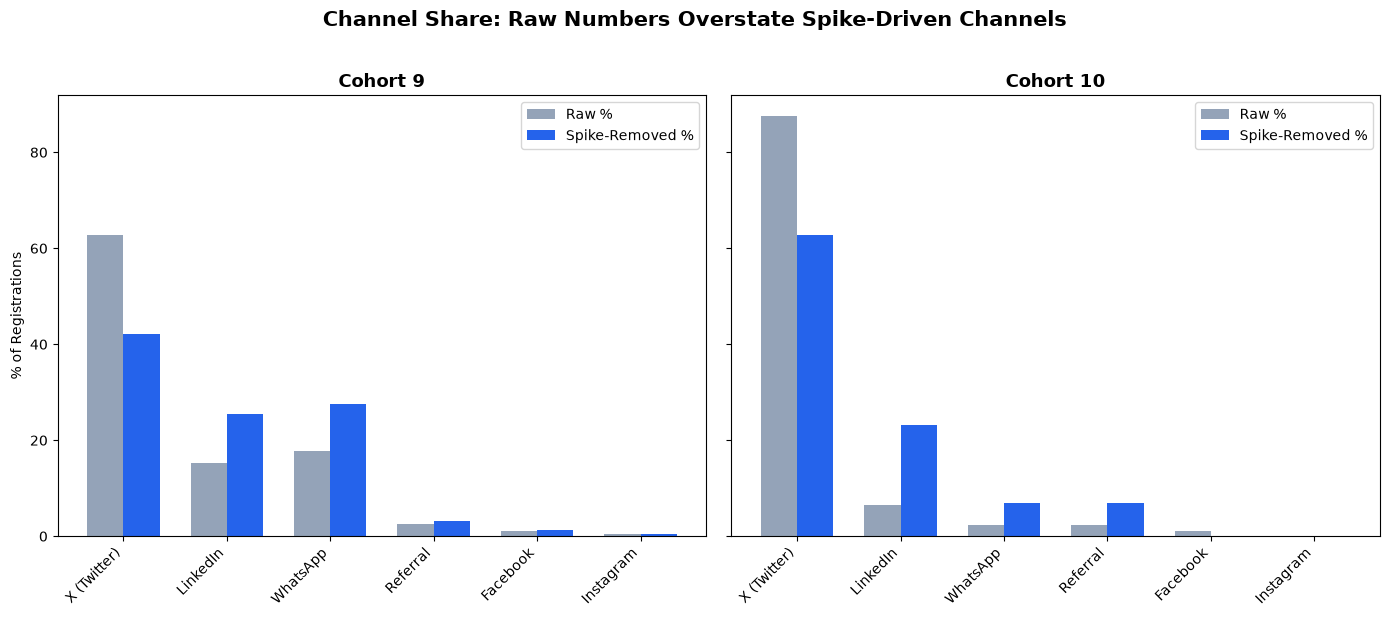

In [3]:
c9_pct = (cohort9['channel_clean'].value_counts(normalize=True) * 100)
c9_no_spike_pct = (cohort9_no_spike['channel_clean'].value_counts(normalize=True) * 100)
c10_pct = (cohort10['channel_clean'].value_counts(normalize=True) * 100)
c10_no_spike_pct = (cohort10_no_spike['channel_clean'].value_counts(normalize=True) * 100)

channels = ['X (Twitter)', 'LinkedIn', 'WhatsApp', 'Referral', 'Facebook', 'Instagram']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

x = np.arange(len(channels))
width = 0.35

for ax, raw, adj, title in [
    (axes[0], c9_pct, c9_no_spike_pct, 'Cohort 9'),
    (axes[1], c10_pct, c10_no_spike_pct, 'Cohort 10')
]:
    raw_vals = [raw.get(c, 0) for c in channels]
    adj_vals = [adj.get(c, 0) for c in channels]
    ax.bar(x - width/2, raw_vals, width, label='Raw %', color='#94a3b8')
    ax.bar(x + width/2, adj_vals, width, label='Spike-Removed %', color='#2563eb')
    ax.set_xticks(x)
    ax.set_xticklabels(channels, rotation=45, ha='right')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()

axes[0].set_ylabel('% of Registrations')
fig.suptitle('Channel Share: Raw Numbers Overstate Spike-Driven Channels', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/chart1_channel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2: Channel Mix — Nigeria vs. International

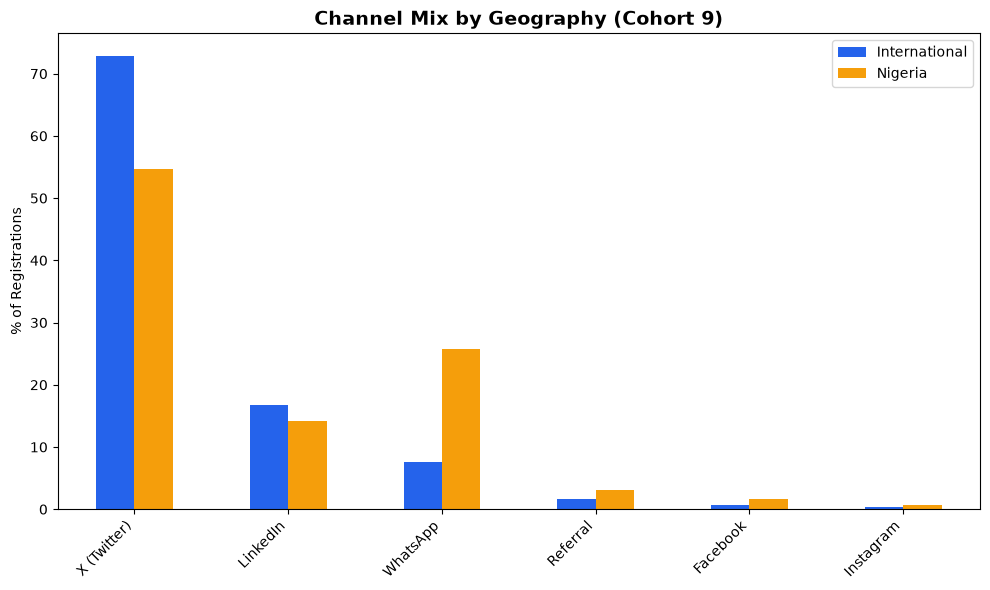

In [4]:
country_map_9 = {'nigeria': 'Nigeria', 'south africa': 'South Africa', 'ghana': 'Ghana', 'kenya': 'Kenya'}  # placeholder, real mapping already in processed data via country_clean
cohort9['is_nigeria'] = cohort9['country_clean'] == 'Nigeria'
cohort10['is_nigeria'] = cohort10['country_clean'] == 'Nigeria'

c9_geo = pd.crosstab(cohort9['is_nigeria'], cohort9['channel_clean'], normalize='index') * 100
c9_geo.index = ['International', 'Nigeria']

fig, ax = plt.subplots(figsize=(10, 6))
c9_geo[channels].T.plot(kind='bar', ax=ax, color=['#2563eb', '#f59e0b'])
ax.set_ylabel('% of Registrations')
ax.set_title('Channel Mix by Geography (Cohort 9)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='')
plt.tight_layout()
plt.savefig('../outputs/chart2_geo_channel_mix.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3: Course Share (Common Courses Only)

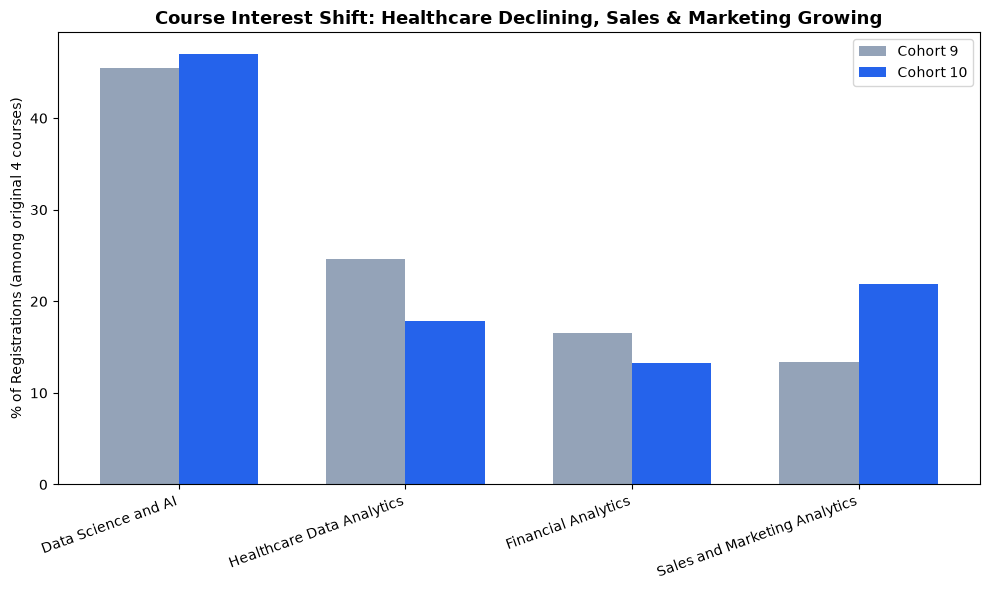

In [6]:
common_courses = ['Data Science and AI', 'Sales and Marketing Analytics', 'Healthcare Data Analytics', 'Financial Analytics']

cohort9['course_clean'] = cohort9['Choice of Program'].str.strip()
cohort10['course_clean'] = cohort10['CHOICE OF COURSE'].str.strip()

cohort10_common = cohort10[cohort10['course_clean'].isin(['Data science and ML', 'Sales and Marketing Analytics', 'Healthcare Data Analytics', 'Financial Analytics'])].copy()
cohort10_common['course_clean'] = cohort10_common['course_clean'].replace('Data science and ML', 'Data Science and AI')

c9_course_pct = (cohort9['course_clean'].value_counts(normalize=True) * 100)
c10_course_pct = (cohort10_common['course_clean'].value_counts(normalize=True) * 100)

course_labels = ['Data Science and AI', 'Healthcare Data Analytics', 'Financial Analytics', 'Sales and Marketing Analytics']

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(course_labels))
width = 0.35

ax.bar(x - width/2, [c9_course_pct.get(c, 0) for c in course_labels], width, label='Cohort 9', color='#94a3b8')
ax.bar(x + width/2, [c10_course_pct.get(c, 0) for c in course_labels], width, label='Cohort 10', color='#2563eb')

ax.set_xticks(x)
ax.set_xticklabels(course_labels, rotation=20, ha='right')
ax.set_ylabel('% of Registrations (among original 4 courses)')
ax.set_title('Course Interest Shift: Healthcare Declining, Sales & Marketing Growing', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/chart3_course_shift.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4: Registration Volume Over Time — The Spike Events

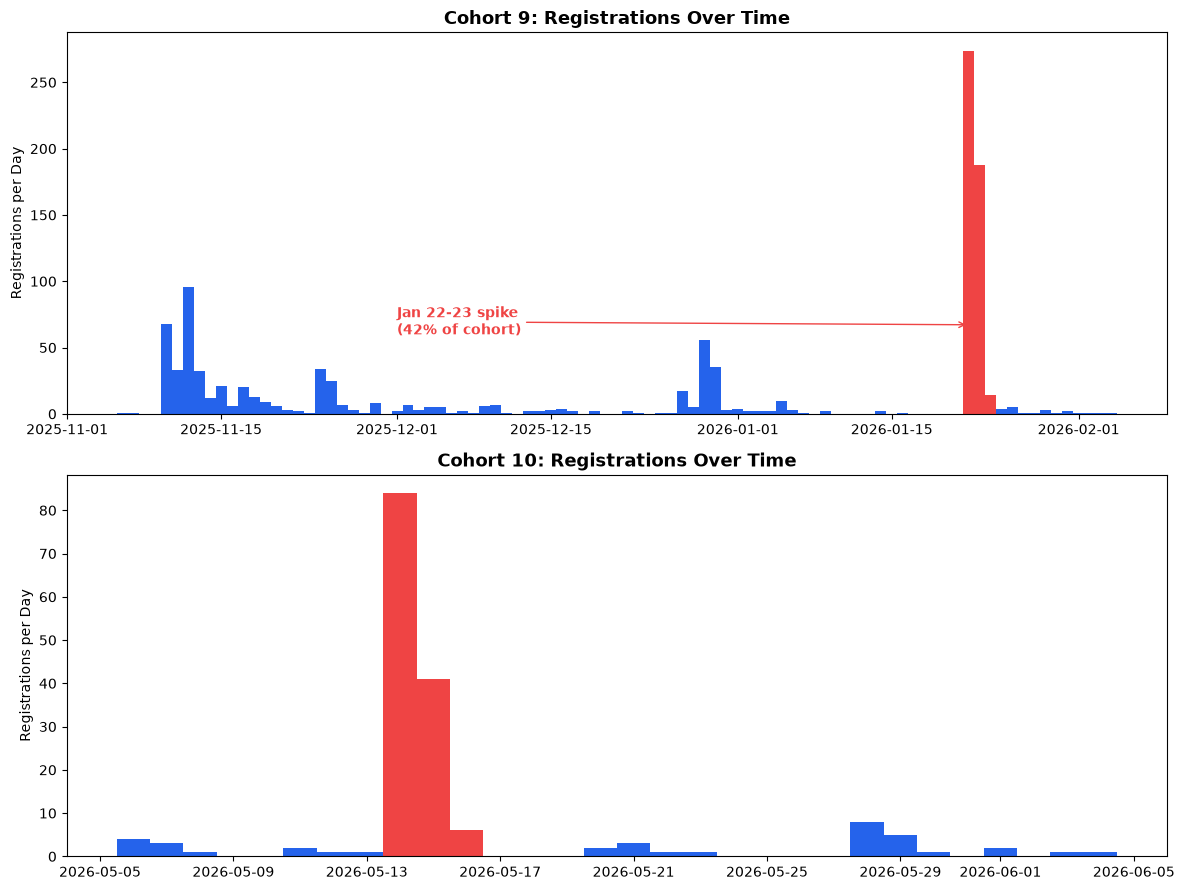

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

for ax, df, spike_start, spike_end, title in [
    (axes[0], cohort9, '2026-01-22', '2026-01-23', 'Cohort 9: Registrations Over Time'),
    (axes[1], cohort10, '2026-05-14', '2026-05-15', 'Cohort 10: Registrations Over Time')
]:
    daily = df.set_index('Timestamp').resample('D').size()
    colors = ['#ef4444' if (pd.Timestamp(spike_start) <= d <= pd.Timestamp(spike_end) + pd.Timedelta(days=1)) else '#2563eb' for d in daily.index]
    ax.bar(daily.index, daily.values, color=colors, width=1.0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Registrations per Day')

axes[0].annotate('Jan 22-23 spike\n(42% of cohort)', xy=(pd.Timestamp('2026-01-22'), daily.max()*0.8),
                  xytext=(pd.Timestamp('2025-12-01'), 60), fontsize=10, color='#ef4444', fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='#ef4444'))

plt.tight_layout()
plt.savefig('../outputs/chart4_timing_spikes.png', dpi=150, bbox_inches='tight')
plt.show()

## Combined Dashboard View

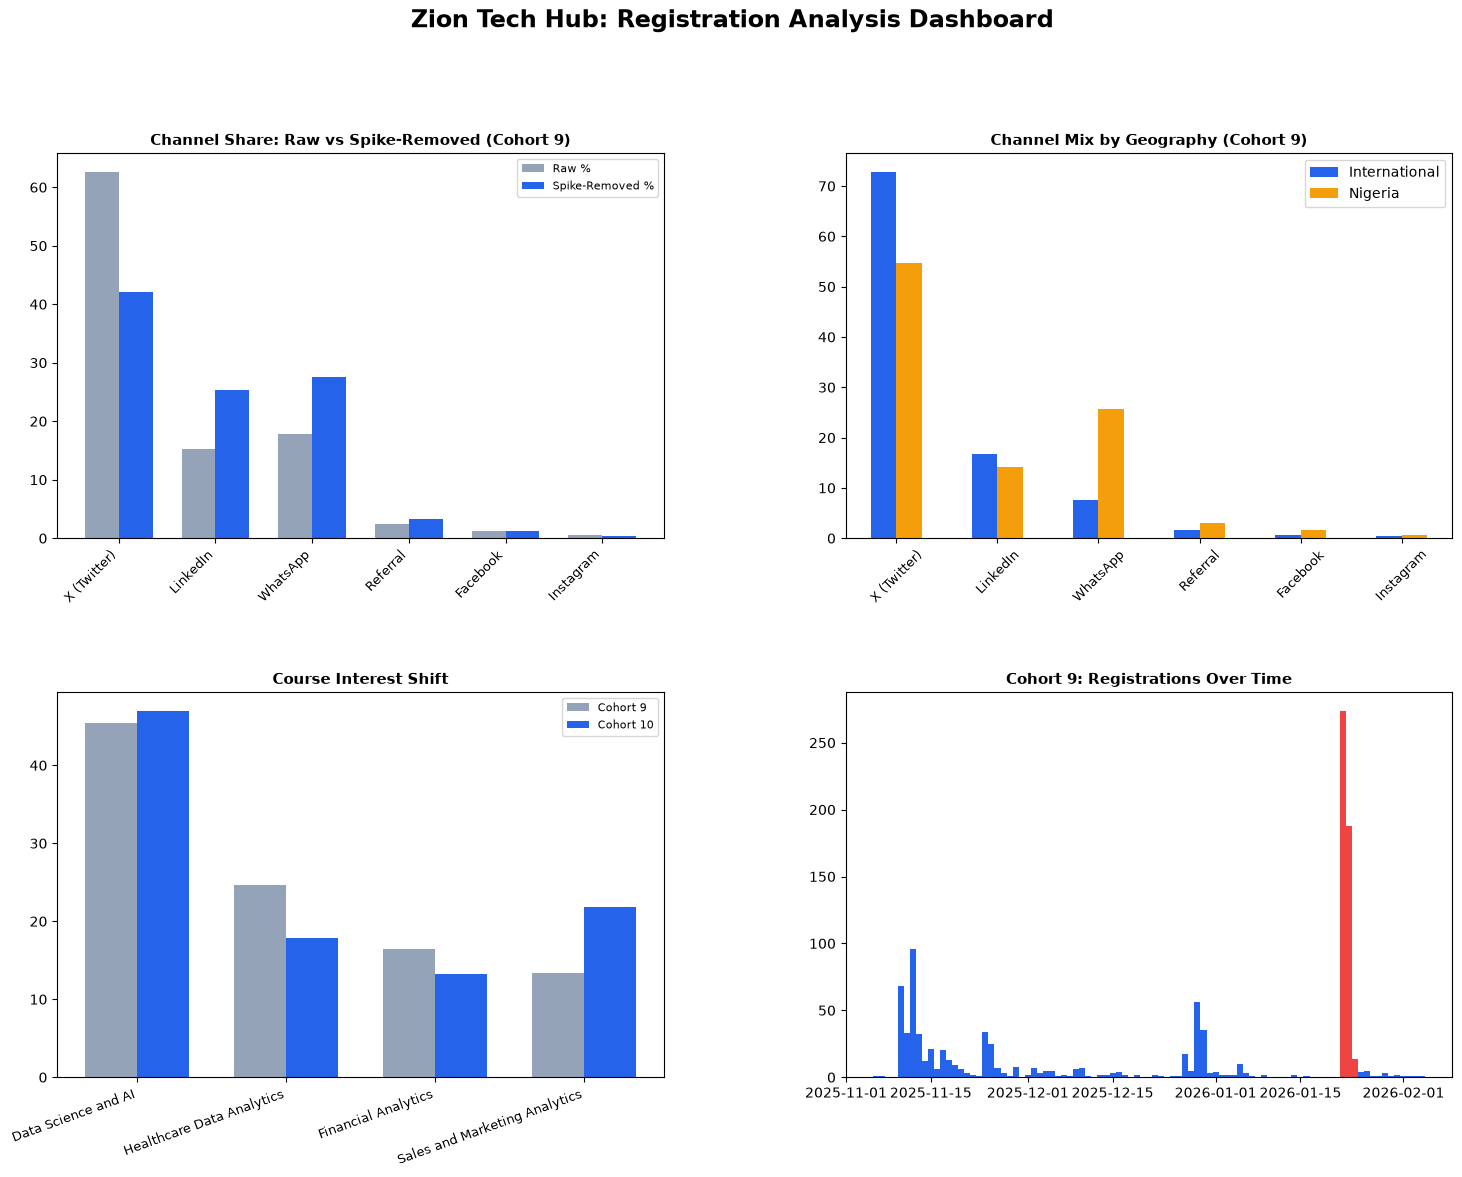

In [8]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Panel 1: Channel comparison (Cohort 9 only, to keep it readable in a smaller panel)
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(channels))
width = 0.35
ax1.bar(x - width/2, [c9_pct.get(c, 0) for c in channels], width, label='Raw %', color='#94a3b8')
ax1.bar(x + width/2, [c9_no_spike_pct.get(c, 0) for c in channels], width, label='Spike-Removed %', color='#2563eb')
ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=45, ha='right', fontsize=9)
ax1.set_title('Channel Share: Raw vs Spike-Removed (Cohort 9)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)

# Panel 2: Geography x Channel
ax2 = fig.add_subplot(gs[0, 1])
c9_geo[channels].T.plot(kind='bar', ax=ax2, color=['#2563eb', '#f59e0b'], legend=True)
ax2.set_title('Channel Mix by Geography (Cohort 9)', fontsize=11, fontweight='bold')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45, labelsize=9)

# Panel 3: Course shift
ax3 = fig.add_subplot(gs[1, 0])
x2 = np.arange(len(course_labels))
ax3.bar(x2 - width/2, [c9_course_pct.get(c, 0) for c in course_labels], width, label='Cohort 9', color='#94a3b8')
ax3.bar(x2 + width/2, [c10_course_pct.get(c, 0) for c in course_labels], width, label='Cohort 10', color='#2563eb')
ax3.set_xticks(x2)
ax3.set_xticklabels(course_labels, rotation=20, ha='right', fontsize=9)
ax3.set_title('Course Interest Shift', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8)

# Panel 4: Timing spike (Cohort 9 only, for space)
ax4 = fig.add_subplot(gs[1, 1])
daily9 = cohort9.set_index('Timestamp').resample('D').size()
colors9 = ['#ef4444' if (pd.Timestamp('2026-01-22') <= d <= pd.Timestamp('2026-01-24')) else '#2563eb' for d in daily9.index]
ax4.bar(daily9.index, daily9.values, color=colors9, width=1.0)
ax4.set_title('Cohort 9: Registrations Over Time', fontsize=11, fontweight='bold')

fig.suptitle('Zion Tech Hub: Registration Analysis Dashboard', fontsize=17, fontweight='bold', y=1.0)
plt.savefig('../outputs/dashboard_combined.png', dpi=150, bbox_inches='tight')
plt.show()